# Modules

In [1]:
import sys
sys.path.insert(1, "../../module")
import numpy as np      
import snflics
from skimage.transform import resize
from netCDF4 import Dataset                             
from scipy.ndimage import zoom
from matplotlib.patches import Rectangle                
import cartopy.crs as ccrs                              
import cartopy.feature as cfeature                   
import matplotlib.pyplot as plt                         
plt.style.use('default')                               
plt.rcParams['figure.facecolor'] = 'white'
import warnings
warnings.filterwarnings("ignore")

# Geodata

## Grid Information Summary

original information

- `lats.shape == lons.shape == cores.shape == (2268, 2080)`
- `lats` and `lons` provide the geolocation (latitude and longitude) for each pixel in `cores`
- The grid is **not regular in geographic space** — the spacing between neighbouring lat/lon values **varies** across the array
- This is known as a **curvilinear grid**

In [2]:
# lat and lon meshgrids
geodata = np.load("../../data/geodata/lat_lon_2268_2080.npz")
lons = geodata["lon"][:]
lats = geodata["lat"][:]

# Dakar lat lon
Dakar_lon = -17.467686
Dakar_lat = 14.716677

# Core data 

In [3]:
lats.shape

(2080, 2268)

In [4]:
year = '2020'
month = '07'
day = '20'
hour = '16'
minute = '45'

In [5]:
path_core = f'/gws/nopw/j04/cocoon/SSA_domain/ch9_wavelet/{year}/{month}'

In [6]:
# file of interest at time t0
file = f'{path_core}/{year}{month}{day}{hour}{minute}.nc'

data = Dataset(file, mode='r')

# wavelet power maxima's coordinates
x0_lat = data["max_lat"][:]
x0_lon = data["max_lon"][:]

# cloud top temperature and wavelet power arrays
temp = data["tir"][0, :, :]
cores = data["cores"][0, :, :]
binary_cores = (cores != 0).astype(int)

# Plot Dakar Context Domain with Core Data

In [7]:
cores.shape

(2080, 2268)

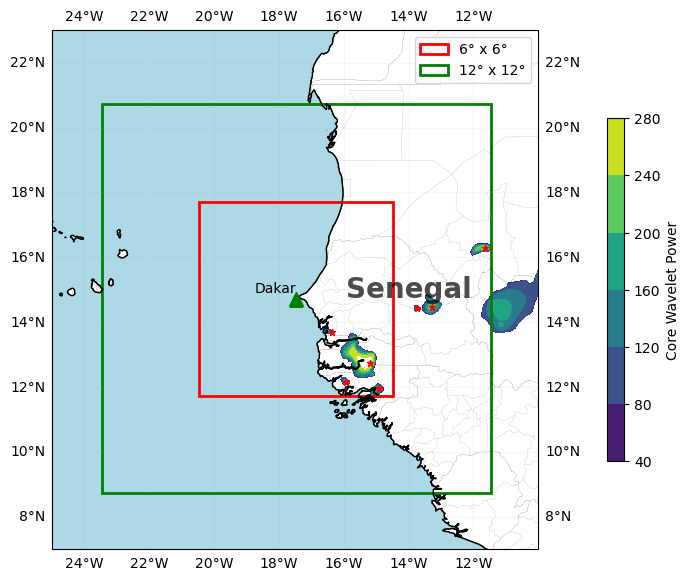

In [8]:
# Define extent
extent = (-25, -10, 7, 23)

# Create figure and axis
fig, ax = plt.subplots(figsize=(7, 10), subplot_kw={'projection': ccrs.PlateCarree()})

# Set map extent
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.1)
ax.add_feature(cfeature.COASTLINE, edgecolor='black')

# Force LAND to be white
ax.add_feature(cfeature.LAND, facecolor='white', edgecolor='black')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

gl = ax.gridlines(xlocs=np.arange(-26, -8, 2), 
                  ylocs=np.arange(8, 23, 2), 
                  draw_labels=True, 
                  crs=ccrs.PlateCarree(),
                  alpha=0.1
                )

# Add administrative borders
admin_borders = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='10m',
    facecolor='none'
)

# display core data
ax.add_feature(admin_borders, edgecolor='black', linewidth=0.06)
contour_core = ax.contourf(lons, lats, cores, levels=[40, 80, 120, 160, 200, 240, 280], transform=ccrs.PlateCarree(), cmap="viridis")

cbar_core = plt.colorbar(contour_core, fraction=0.03, pad=0.12)
cbar_core.set_label("Core Wavelet Power")

ax.text(-14, 15, "Senegal", fontsize=20, fontweight="bold", color="black",
        transform=ccrs.PlateCarree(), ha="center", va="center", alpha=0.7)

box_sizes = [6, 12]
colors = ['red', 'green']
labels = ['6° x 6°', '12° x 12°']

# Add rectangles
for size, color, label in zip(box_sizes, colors, labels):
    lower_left_lon = Dakar_lon - size / 2
    lower_left_lat = Dakar_lat - size / 2
    rect = Rectangle((lower_left_lon, lower_left_lat), size, size,
                     linewidth=2, edgecolor=color, facecolor='none', label=label)
    ax.add_patch(rect)

for lt, ln in zip(x0_lat, x0_lon):    
  plt.plot(ln, lt, marker="*", color="red", markersize=5)

# Plot a marker at Dakar's location
plt.plot(Dakar_lon, Dakar_lat, marker="^", color="green", markersize=10)
plt.text(Dakar_lon, Dakar_lat+0.1, "Dakar", ha="right", va="bottom")
plt.legend()
plt.tight_layout()
plt.show()

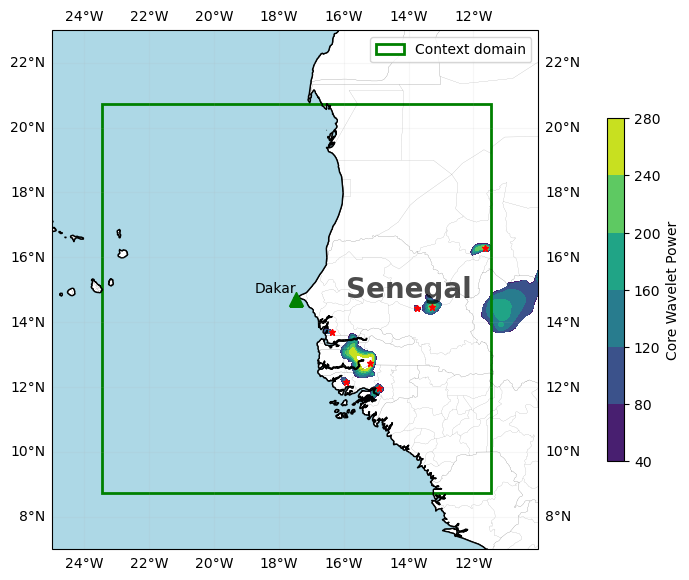

In [9]:
# Define extent
extent = (-25, -10, 7, 23)

# Create figure and axis
fig, ax = plt.subplots(figsize=(7, 10), subplot_kw={'projection': ccrs.PlateCarree()})

# Set map extent
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.1)
ax.add_feature(cfeature.COASTLINE, edgecolor='black')

# Force LAND to be white
ax.add_feature(cfeature.LAND, facecolor='white', edgecolor='black')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

gl = ax.gridlines(xlocs=np.arange(-26, -8, 2), 
                  ylocs=np.arange(8, 23, 2), 
                  draw_labels=True, 
                  crs=ccrs.PlateCarree(),
                  alpha=0.1
                )

# Add administrative borders
admin_borders = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='10m',
    facecolor='none'
)

# display core data
ax.add_feature(admin_borders, edgecolor='black', linewidth=0.06)
contour_core = ax.contourf(lons, lats, cores, levels=[40, 80, 120, 160, 200, 240, 280], transform=ccrs.PlateCarree(), cmap="viridis")

cbar_core = plt.colorbar(contour_core, fraction=0.03, pad=0.12)
cbar_core.set_label("Core Wavelet Power")

ax.text(-14, 15, "Senegal", fontsize=20, fontweight="bold", color="black",
        transform=ccrs.PlateCarree(), ha="center", va="center", alpha=0.7)

box_sizes = [12]
colors = ['green']
labels = ['Context domain']

# Add rectangles
for size, color, label in zip(box_sizes, colors, labels):
    lower_left_lon = Dakar_lon - size / 2
    lower_left_lat = Dakar_lat - size / 2
    rect = Rectangle((lower_left_lon, lower_left_lat), size, size,
                     linewidth=2, edgecolor=color, facecolor='none', label=label)
    ax.add_patch(rect)

for lt, ln in zip(x0_lat, x0_lon):    
  plt.plot(ln, lt, marker="*", color="red", markersize=5)

# Plot a marker at Dakar's location
plt.plot(Dakar_lon, Dakar_lat, marker="^", color="green", markersize=10)
plt.text(Dakar_lon, Dakar_lat+0.1, "Dakar", ha="right", va="bottom")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
for size, label in zip(box_sizes, labels):
    lower_left_lon = Dakar_lon - size / 2
    lower_left_lat = Dakar_lat - size / 2
    print(label, lower_left_lat, lower_left_lon)

Context domain 8.716677 -23.467686


# Retrieving Ground Truth for Dakar

In [11]:
snflics.to_yx(11.716677, -20.467686, lats, lons)

(1639, 14)

In [12]:
Dakar_y, Dakar_x = snflics.to_yx(Dakar_lat, Dakar_lon, lats, lons)

In [13]:
def extract_box(data, y, x, box_size=5, spacing_km=3):
    """
    Extracts a square region around a central grid point and calculates area coverage.

    Parameters:
    -----------
    data : np.ndarray
        2D array from which to extract the box (e.g., cores).
    y, x : int
        Central grid indices.
    box_size : int
        Size of the square box (must be odd), e.g., 5 for a 5x5 box.
    spacing_km : float
        Grid spacing in kilometres.

    Returns:
    --------
    box : np.ndarray
        The extracted subregion.
    extent_km : float
        The physical width/height (in km) of the area covered.
    """
    assert box_size % 2 == 1, "box_size must be odd"
    
    half = box_size // 2
    y_min = max(0, y - half)
    y_max = min(data.shape[0], y + half + 1)
    x_min = max(0, x - half)
    x_max = min(data.shape[1], x + half + 1)
    
    box = data[y_min:y_max, x_min:x_max]

    # physical size from number of intervals
    extent_km = (box.shape[0] - 1) * spacing_km                                     

    return box, extent_km

In [14]:
Dakar_core, _ = extract_box(cores, Dakar_y, Dakar_x, box_size=5)

# Context Domain Coordinates for Dakar

In [15]:
# Shorter lead time
Dakar_context_short_lt_lat_min = 11.69
Dakar_context_short_lt_lat_max = Dakar_context_short_lt_lat_min + 6

Dakar_context_short_lt_lon_min = -20.45
Dakar_context_short_lt_lon_max = Dakar_context_short_lt_lon_min + 6

# Longer lead time
Dakar_context_long_lt_lat_min = 8.69
Dakar_context_long_lt_lat_max = Dakar_context_long_lt_lat_min + 12

Dakar_context_long_lt_lon_min = -23.45
Dakar_context_long_lt_lon_max = Dakar_context_long_lt_lon_min + 12

# Senegal extent

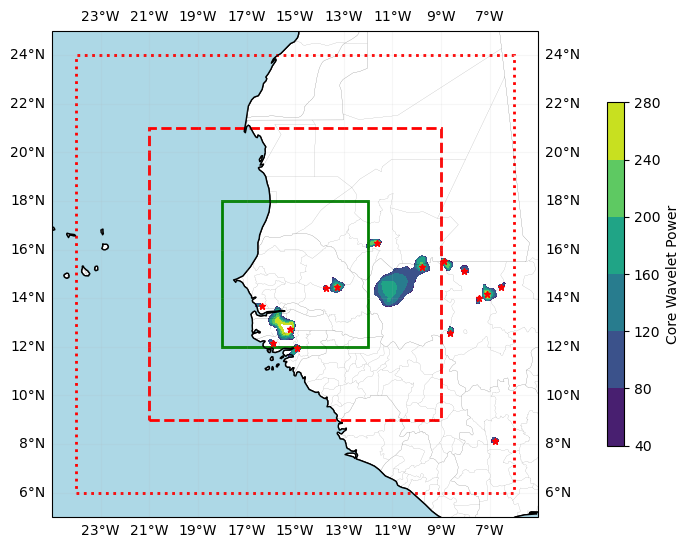

In [16]:
# Define extent
extent = (-25, -5, 5, 25)

# Create figure and axis
fig, ax = plt.subplots(figsize=(7, 10), subplot_kw={'projection': ccrs.PlateCarree()})


# Set map extent
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.1)
ax.add_feature(cfeature.COASTLINE, edgecolor='black')

# Force LAND to be white
ax.add_feature(cfeature.LAND, facecolor='white', edgecolor='black')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')  # Optional

gl = ax.gridlines(xlocs=np.arange(-23, -5, 2), 
                  ylocs=np.arange(6, 25, 2), 
                  draw_labels=True, 
                  crs=ccrs.PlateCarree(),
                  alpha=0.1
                )

# Add administrative borders
admin_borders = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='10m',
    facecolor='none'
)

ax.add_feature(admin_borders, edgecolor='black', linewidth=0.06)
contour_core = ax.contourf(lons, lats, cores, levels=[40, 80, 120, 160, 200, 240, 280], transform=ccrs.PlateCarree(), cmap="viridis")

cbar_core = plt.colorbar(contour_core, fraction=0.03, pad=0.12)
cbar_core.set_label("Core Wavelet Power")

# Add the 6x6 square (green)
ax.add_patch(Rectangle((-18.0, 12.0), 6, 6, edgecolor='green', facecolor='none', linewidth=2))

# Add the 12x12 square (red)
ax.add_patch(Rectangle((-21.0, 9.0), 12, 12, edgecolor='red', facecolor='none', linewidth=2, linestyle="dashed"))

# Add the 18x18 square (red)
ax.add_patch(Rectangle((-24.0, 6.0), 18, 18, edgecolor='red', facecolor='none', linewidth=2, linestyle="dotted"))

for lt, ln in zip(x0_lat, x0_lon):    
  plt.plot(ln, lt, marker="*", color="red", markersize=5)

plt.tight_layout()
plt.show()


# Context Domain Coordinates for Senegal

In [17]:
# Domain of interest
Senegal_lon_min = -18.0
Senegal_lon_max = Senegal_lon_min + 6

Senegal_lat_min = 12.0
Senegal_lat_max = Senegal_lat_min + 6

# Context domain for shorter lead times
Senegal_context_short_lt_lon_min = -21.0
Senegal_context_short_lt_lon_max = Senegal_context_short_lt_lon_min + 12

Senegal_context_short_lt_lat_min = 9.0
Senegal_context_short_lt_lat_max = Senegal_context_short_lt_lat_min + 12

# Context domain for longer lead times
Senegal_context_long_lt_lon_min = -24.0
Senegal_context_long_lt_lon_max = Senegal_context_long_lt_lon_min + 18

Senegal_context_long_lt_lat_min = 6.0
Senegal_context_long_lt_lat_max = Senegal_context_long_lt_lat_min + 18

In [18]:
Senegal_y_min, Senegal_x_min = snflics.to_yx(Senegal_lat_min, Senegal_lon_min, lats, lons)
Senegal_y_max, Senegal_x_max = snflics.to_yx(Senegal_lat_max, Senegal_lon_max, lats, lons)

In [19]:
Senegal_y_min, Senegal_x_min = 1650, 96
Senegal_y_max, Senegal_x_max = 1861, 315

In [20]:
Senegal_core = cores[Senegal_y_min:Senegal_y_max+1, Senegal_x_min:Senegal_x_max+1]
Senegal_domain_lats = lats[Senegal_y_min:Senegal_y_max+1, Senegal_x_min:Senegal_x_max+1]
Senegal_domain_lons = lons[Senegal_y_min:Senegal_y_max+1, Senegal_x_min:Senegal_x_max+1]

In [21]:
target_shape = (32, 32)
zoom_factors = (
    target_shape[0] / Senegal_core.shape[0],
    target_shape[1] / Senegal_core.shape[1],
)

Senegal_core_resized = zoom(Senegal_core, zoom=zoom_factors, order=1)  # bilinear interpolation

lats_resized = resize(Senegal_domain_lats, target_shape, mode='reflect', anti_aliasing=True)
lons_resized = resize(Senegal_domain_lons, target_shape, mode='reflect', anti_aliasing=True)

### 📏 New Grid Resolution After Resizing

The original data had:

- **Shape**: `212 × 220`
- **Grid spacing**: `3 km`

So the total physical area covered is:

- **Height**: `212 × 3 km = 636 km`
- **Width**: `220 × 3 km = 660 km`

After resizing to `128 × 128`, we cover the same area but with fewer grid cells.

#### 🧮 New resolution:

- **Vertical spacing**: `636 km / 128 ≈ 4.97 km`
- **Horizontal spacing**: `660 km / 128 ≈ 5.16 km`

---

✅ **Result:**  
The new effective resolution is approximately:

- **5.0 km** per pixel (latitude direction)  
- **5.2 km** per pixel (longitude direction)


# Focus on Senegal

In [22]:
def plot_core_Senegal(lats_2dgrid, lons_2dgrid, value_2d):

    # Define extent
    extent = (-18, -12, 12, 18)
    projection = ccrs.PlateCarree()

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(7, 10), subplot_kw={'projection': projection})

    # Force background to white
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    # Set map extent
    ax.set_extent(extent, crs=projection)

    # Add map features
    ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.1)
    ax.add_feature(cfeature.COASTLINE, edgecolor='black')

    # Force LAND to be white
    ax.add_feature(cfeature.LAND, facecolor='white', edgecolor='black')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue') 

    gl = ax.gridlines(xlocs=np.arange(-23, -5, 2), 
                    ylocs=np.arange(6, 25, 2), 
                    draw_labels=True, 
                    crs=projection,
                    alpha=0.1
                    )

    # Add administrative borders
    admin_borders = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lines',
        scale='10m',
        facecolor='none'
    )

    ax.add_feature(admin_borders, edgecolor='black', linewidth=0.06)
    contour_core = ax.contourf(lons_2dgrid, lats_2dgrid, value_2d, levels=[40, 80, 120, 160, 200, 240, 280], transform=projection, cmap="viridis")

    cbar_core = plt.colorbar(contour_core, fraction=0.03, pad=0.12)
    cbar_core.set_label("Core Wavelet Power")


    plt.tight_layout()
    plt.show()

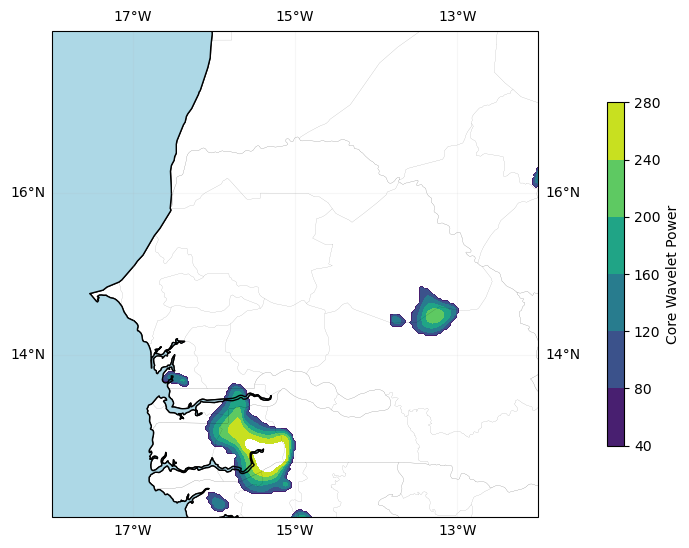

In [23]:
plot_core_Senegal(lats, lons, cores)

# Plot here resized data

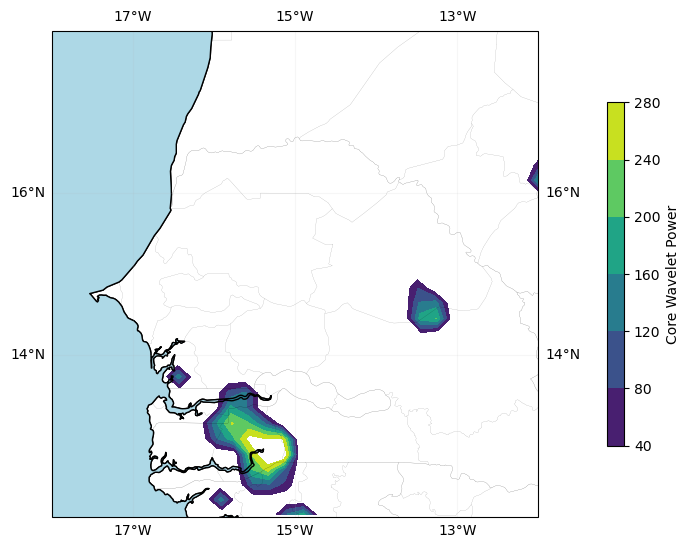

In [24]:
plot_core_Senegal(lats_resized, lons_resized, Senegal_core_resized)